FL on MNIST — Stage 1 and Stage 2 Notebook Guide

This notebook-style guide contains both stages your supervisor asked for:

Stage 1: 10 clients, IID split, MNIST, 2NN, accuracy vs training round
Stage 2: 10 clients, non-IID split where each client has one label, MNIST, 2NN, accuracy vs training round

You can copy the code cells into a Jupyter notebook, or keep them as a Python script.

Cell 1 — Imports

In [1]:
import argparse
import copy
import random
from collections import OrderedDict, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim import SGD
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

Cell 2 — Reproducibility

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Cell 3 — Model: 2NN

Why 2NN first:

easier to debug than CNN
faster to run
enough to clearly show IID vs non-IID behavior in FL

In [3]:
class TwoNN(nn.Module):
    def __init__(self, input_dim=28 * 28, hidden_dim=200, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

Cell 4 — Model parameter utilities

In [ ]:
def get_model_params(model: nn.Module):  # Returns a copy of the model's parameters as an OrderedDict
    return OrderedDict((k, v.detach().clone()) for k, v in model.state_dict().items())


def set_model_params(model: nn.Module, params):  # Sets the model's parameters from an OrderedDict
    model.load_state_dict(params, strict=True)


def subtract_params(new_params, old_params):  # Subtracts two sets of parameters
    return OrderedDict((k, new_params[k] - old_params[k]) for k in new_params.keys()) 


def add_params(a, b): # Adds two sets of parameters
    return OrderedDict((k, a[k] + b[k]) for k in a.keys())


def scale_params(params, scalar: float): # Scales a set of parameters by a scalar
    return OrderedDict((k, v * scalar) for k, v in params.items())


def zeros_like_params(params): # Creates a new set of parameters with the same keys but all values set to zero
    return OrderedDict((k, torch.zeros_like(v)) for k, v in params.items())

Cell 5 — Load MNIST

Data is downloaded automatically into ./data.

In [ ]:
def load_mnist(data_root: str = "./data"): 
    transform = transforms.ToTensor()
    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)  #
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)
    return train_ds, test_ds

Cell 6 — Stage 1 data partition: IID

This shuffles all training samples and splits them equally among 10 clients.

In [ ]:
# Randomly shuffles the dataset indices
# Divides them evenly across clients
# Creates a separate dataset for each client

def partition_iid(dataset, num_clients=10, seed=42):
    rng = np.random.default_rng(seed) # Generator function: whCreate a random number generator with the given seed for reproducibility
    indices = np.arange(len(dataset)) # Create an array of indices corresponding to the dataset samples
    rng.shuffle(indices) # Shuffle the indices to randomize the order of the samples

    shard_size = len(indices) // num_clients
    subsets = []
    for i in range(num_clients):
        start = i * shard_size
        end = (i + 1) * shard_size if i < num_clients - 1 else len(indices)
        subsets.append(Subset(dataset, indices[start:end].tolist())) # tolist() converts the numpy array slice to a Python list, which is required by the Subset class
    return subsets

Cell 7 — Stage 2 data partition: one-label non-IID

This is the extreme non-IID setting your supervisor described:

client 0 gets label 0 only
client 1 gets label 1 only
...
client 9 gets label 9 only

In [ ]:
# This function does the following:
# make sure the number of clients is exactly 10
# create a dictionary that will map each label to a list of dataset positions
# scan through the whole dataset
# for each sample, put its index into the list for its label
# create an empty list of client datasets
# for each client ID from 0 to 9:
# take all indices of that label
# make a subset from the original dataset
# add it to the list
# return the list of client subsets

def partition_one_label_per_client(dataset, num_clients=10):
    if num_clients != 10:
        raise ValueError("This one-label-per-client stage is defined for exactly 10 clients.")

    label_to_indices = defaultdict(list) # if a new key is used for the first time, automatically create an empty list [] for it
    for idx, (_, label) in enumerate(dataset):
        label_to_indices[int(label)].append(idx)

    subsets = []
    for client_id in range(num_clients):
        subsets.append(Subset(dataset, label_to_indices[client_id]))
    return subsets

Cell 8 — DataLoaders

In [ ]:
def make_loaders(train_subsets, test_ds, batch_size=64, test_batch_size=256):
    # Create a DataLoader for each client subset with the specified batch size and shuffling enabled for training, and a single DataLoader for the test dataset with a larger batch size and shuffling
    train_loaders = [
        DataLoader(subset, batch_size=batch_size, shuffle=True)
        for subset in train_subsets
    ]
    test_loader = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    return train_loaders, test_loader

Cell 9 — FL Client

Each client:

receives global parameters
trains locally
computes update = final params - initial params

In [ ]:
class FLClient:
    def __init__(self, client_id, model, loader, lr, local_epochs, device):
        self.client_id = client_id
        self.model = model.to(device)
        self.loader = loader
        self.lr = lr
        self.local_epochs = local_epochs
        self.device = device

    def train(self, global_params):
        set_model_params(self.model, global_params)
        initial_params = get_model_params(self.model)

        self.model.train()
        optimizer = SGD(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        loss_sum = 0.0
        count = 0

        for _ in range(self.local_epochs):
            for x, y in self.loader:
                x, y = x.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                logits = self.model(x)
                loss = criterion(logits, y) # Compute the loss between the model's predictions (logits) and the true labels (y) using the cross-entropy loss function
                loss.backward()  # Compute the gradients of the loss with respect to the model parameters
                optimizer.step() #

                loss_sum += loss.item() * y.size(0)  # Accumulate the total loss across all samples in the loader, multiplying by the batch size to get the total loss for that batch
                count += y.size(0)  # Keep track of the total number of samples processed to compute the average loss

        final_params = get_model_params(self.model)
        update = subtract_params(final_params, initial_params)

        return {
            "client_id": self.client_id,
            "num_samples": len(self.loader.dataset),
            "update": update,
            "local_loss": loss_sum / max(count, 1),
        }

Cell 10 — FL Server (FedAvg)

In [ ]:
class FLServer:
    def __init__(self, initial_params):
        self.global_params = initial_params

    def aggregate(self, client_results):
        total_samples = sum(r["num_samples"] for r in client_results)
        agg_update = zeros_like_params(client_results[0]["update"])

        for result in client_results:
            weight = result["num_samples"] / total_samples
            weighted_update = scale_params(result["update"], weight)
            
                    #             OrderedDict({
                    #     "layer1.weight": tensor(...),
                    #     "layer1.bias": tensor(...),
                    #     ...
                    # })
            agg_update = add_params(agg_update, weighted_update)  

        self.global_params = add_params(self.global_params, agg_update)

Cell 11 — Evaluation

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    correct = 0   # Initialize a counter for the number of correct predictions
    total = 0     # Initialize a counter for the total number of samples
    loss_sum = 0.0  # Initialize a variable to accumulate the total loss

    with torch.no_grad():  # Disable gradient computation for evaluation
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)  # Compute the loss between the model's predictions (logits) and the true labels (y) using the cross-entropy loss function

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item() # Add the number of correct predictions in the current batch to the total count of correct predictions 
            total += y.size(0)  # dimension 0 of y corresponds to the batch size, so this adds the number of samples in the current batch to the total count
            loss_sum += loss.item() * y.size(0)

    return {
        "accuracy": correct / total,
        "loss": loss_sum / total,
    }

Cell 12 — Main experiment runner

This function runs either Stage 1 or Stage 2.

In [12]:
def run_federated_experiment(
    stage: str,
    data_root: str = "./data",
    num_clients: int = 10,
    rounds: int = 20,
    batch_size: int = 64,
    test_batch_size: int = 256,
    lr: float = 0.05,
    local_epochs: int = 1,
    hidden_dim: int = 200,
    seed: int = 42,
    device: str = "cpu",
):
    set_seed(seed)

    train_ds, test_ds = load_mnist(data_root)

    if stage == "iid":
        train_subsets = partition_iid(train_ds, num_clients=num_clients, seed=seed)
        title = "Stage 1: IID FL on MNIST"
        out_plot = "stage1_iid_accuracy_vs_round.png"
        out_csv = "stage1_iid_metrics.csv"
    elif stage == "label_noniid":
        train_subsets = partition_one_label_per_client(train_ds, num_clients=num_clients)
        title = "Stage 2: Extreme Non-IID FL (One Label per Client)"
        out_plot = "stage2_label_noniid_accuracy_vs_round.png"
        out_csv = "stage2_label_noniid_metrics.csv"
    else:
        raise ValueError("stage must be either 'iid' or 'label_noniid'")

    train_loaders, test_loader = make_loaders(
        train_subsets,
        test_ds,
        batch_size=batch_size,
        test_batch_size=test_batch_size,
    )

    base_model = TwoNN(hidden_dim=hidden_dim).to(device)
    initial_params = get_model_params(base_model)
    server = FLServer(initial_params=initial_params)

    clients = [
        FLClient(
            client_id=i,
            model=TwoNN(hidden_dim=hidden_dim),
            loader=train_loaders[i],
            lr=lr,
            local_epochs=local_epochs,
            device=device,
        )
        for i in range(num_clients)
    ]

    history = []

    for rnd in range(1, rounds + 1):
        global_params = copy.deepcopy(server.global_params)

        client_results = []
        for client in clients:
            result = client.train(global_params)
            client_results.append(result)

        server.aggregate(client_results)

        eval_model = TwoNN(hidden_dim=hidden_dim).to(device)
        set_model_params(eval_model, server.global_params)
        eval_result = evaluate(eval_model, test_loader, device=device)

        avg_local_loss = sum(r["local_loss"] for r in client_results) / len(client_results)

        history.append(
            {
                "round": rnd,
                "test_accuracy": eval_result["accuracy"],
                "test_loss": eval_result["loss"],
                "avg_client_local_loss": avg_local_loss,
            }
        )

        print(
            f"Round {rnd:02d} | "
            f"test_acc={eval_result['accuracy']:.4f} | "
            f"test_loss={eval_result['loss']:.4f} | "
            f"avg_local_loss={avg_local_loss:.4f}"
        )

    df = pd.DataFrame(history)
    df.to_csv(out_csv, index=False)

    plt.figure(figsize=(8, 4))
    plt.plot(df["round"], df["test_accuracy"], marker="o")
    plt.xlabel("Training Round")
    plt.ylabel("Test Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_plot)
    plt.show()

    print(f"\nSaved metrics to: {out_csv}")
    print(f"Saved plot to:    {out_plot}")

    return df

Cell 13 — Device setup

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


Cell 14 — Run Stage 1 (IID)

Round 01 | test_acc=0.8057 | test_loss=1.0157 | avg_local_loss=1.6954
Round 02 | test_acc=0.8639 | test_loss=0.5872 | avg_local_loss=0.7774
Round 03 | test_acc=0.8825 | test_loss=0.4633 | avg_local_loss=0.5444
Round 04 | test_acc=0.8925 | test_loss=0.4050 | avg_local_loss=0.4579
Round 05 | test_acc=0.8989 | test_loss=0.3719 | avg_local_loss=0.4130
Round 06 | test_acc=0.9029 | test_loss=0.3491 | avg_local_loss=0.3841
Round 07 | test_acc=0.9076 | test_loss=0.3328 | avg_local_loss=0.3646
Round 08 | test_acc=0.9106 | test_loss=0.3202 | avg_local_loss=0.3487
Round 09 | test_acc=0.9142 | test_loss=0.3092 | avg_local_loss=0.3359
Round 10 | test_acc=0.9170 | test_loss=0.3003 | avg_local_loss=0.3246
Round 11 | test_acc=0.9185 | test_loss=0.2938 | avg_local_loss=0.3151
Round 12 | test_acc=0.9204 | test_loss=0.2842 | avg_local_loss=0.3064
Round 13 | test_acc=0.9223 | test_loss=0.2779 | avg_local_loss=0.2986
Round 14 | test_acc=0.9231 | test_loss=0.2720 | avg_local_loss=0.2912
Round 15 | test_acc=

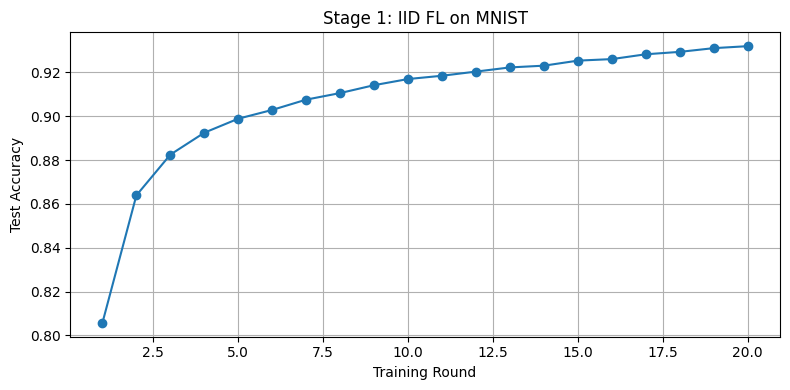


Saved metrics to: stage1_iid_metrics.csv
Saved plot to:    stage1_iid_accuracy_vs_round.png


In [14]:
df_stage1 = run_federated_experiment(
    stage="iid",
    data_root="./data",
    num_clients=10,
    rounds=20,
    batch_size=64,
    test_batch_size=256,
    lr=0.05,
    local_epochs=1,
    hidden_dim=200,
    seed=42,
    device=device,
)

Cell 15 — Run Stage 2 (One-label non-IID)

Round 01 | test_acc=0.2185 | test_loss=2.2316 | avg_local_loss=0.1035
Round 02 | test_acc=0.3383 | test_loss=2.1534 | avg_local_loss=0.0617
Round 03 | test_acc=0.3849 | test_loss=2.0874 | avg_local_loss=0.0463
Round 04 | test_acc=0.4507 | test_loss=2.0298 | avg_local_loss=0.0389
Round 05 | test_acc=0.5015 | test_loss=1.9784 | avg_local_loss=0.0344
Round 06 | test_acc=0.5407 | test_loss=1.9310 | avg_local_loss=0.0316
Round 07 | test_acc=0.5671 | test_loss=1.8867 | avg_local_loss=0.0294
Round 08 | test_acc=0.5852 | test_loss=1.8457 | avg_local_loss=0.0274
Round 09 | test_acc=0.5961 | test_loss=1.8061 | avg_local_loss=0.0259
Round 10 | test_acc=0.6110 | test_loss=1.7675 | avg_local_loss=0.0252
Round 11 | test_acc=0.6234 | test_loss=1.7318 | avg_local_loss=0.0241
Round 12 | test_acc=0.6342 | test_loss=1.6971 | avg_local_loss=0.0232
Round 13 | test_acc=0.6462 | test_loss=1.6635 | avg_local_loss=0.0224
Round 14 | test_acc=0.6573 | test_loss=1.6319 | avg_local_loss=0.0220
Round 15 | test_acc=

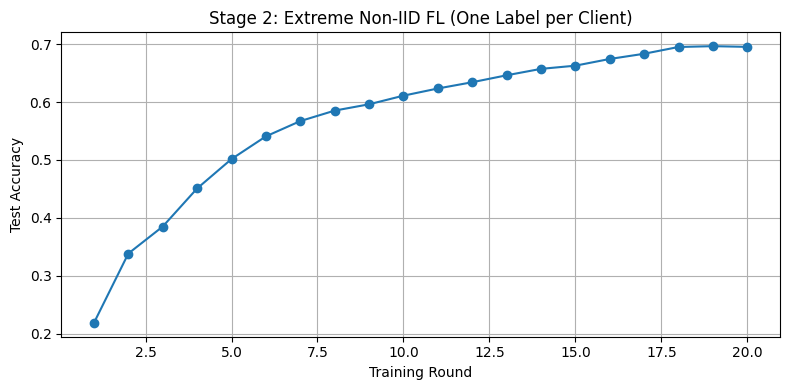


Saved metrics to: stage2_label_noniid_metrics.csv
Saved plot to:    stage2_label_noniid_accuracy_vs_round.png


In [15]:
df_stage2 = run_federated_experiment(
    stage="label_noniid",
    data_root="./data",
    num_clients=10,
    rounds=20,
    batch_size=64,
    test_batch_size=256,
    lr=0.05,
    local_epochs=1,
    hidden_dim=200,
    seed=42,
    device=device,
)

Cell 16 — Optional comparison plot in one figure

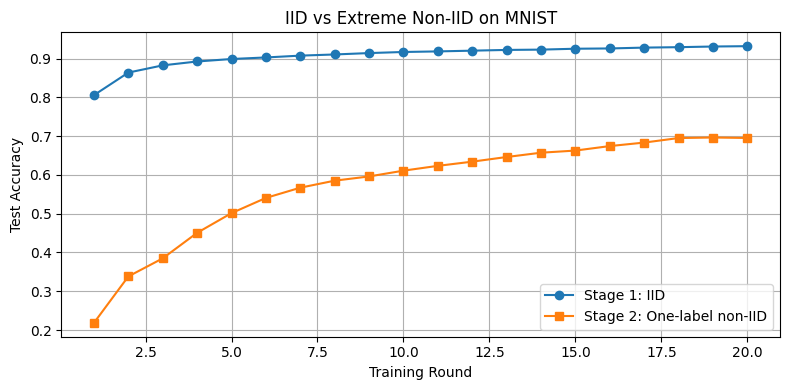

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(df_stage1["round"], df_stage1["test_accuracy"], marker="o", label="Stage 1: IID")
plt.plot(df_stage2["round"], df_stage2["test_accuracy"], marker="s", label="Stage 2: One-label non-IID")
plt.xlabel("Training Round")
plt.ylabel("Test Accuracy")
plt.title("IID vs Extreme Non-IID on MNIST")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("iid_vs_label_noniid_comparison.png")
plt.show()